In [ ]:
# Colab cell 0 - minimal mode (fast)
!pip install pandas numpy scipy matplotlib seaborn scikit-learn plotly scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 3.6 MB/s eta 0:00:00


### Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = '/content/drive/MyDrive/datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate1_detected_transcripts_S2R1.zip'
csv_name_inside_zip = 'datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate1_detected_transcripts_S2R1.csv'

In [ ]:
import pandas as pd
import zipfile
import os

# Create a directory to extract the contents
extract_dir = '/content/mouse_brain_merfish_mRNA_data/'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Construct the full path to the extracted CSV file
csv_file_path = os.path.join(extract_dir, csv_name_inside_zip)

# Load the CSV into a Pandas DataFrame
df = pd.read_csv(csv_file_path)

In [ ]:
# Display the first 5 rows (default) of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())


First 5 rows of the DataFrame:
   Unnamed: 0  barcode_id    global_x   global_y  global_z           x  \
0           0          22   56.930107  3851.8510       5.0   147.80061   
1           1          22  183.601070  3874.0085       5.0  1320.67990   
2           2          22   59.750736  3666.5576       5.0   132.66754   
3           3         204   93.463020  3573.8591       0.0   444.81827   
4           4         234   83.457310  3479.3071       0.0   352.17288   

            y  fov    gene  
0  1711.90670    0  Adgre1  
1  1917.06920    0  Adgre1  
2  1844.23720    1  Adgre1  
3   985.91930    1    Grm4  
4   110.43845    1  P2yr13  


###  A) - imports and basic settings

In [ ]:
import os, time, gc, math
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import plotly.graph_objs as go
import plotly.express as px
import matplotlib.pyplot as plt

# # Output directory for saved plots
OUTDIR = '/content/merfish_visuals'
os.makedirs(OUTDIR, exist_ok=True)

# Parameters you can tweak
z_spacing = 1.5           # microns per z slice in Vizgen data
downsample_plot = 150000  # number of background points to draw in "before" plot
radius_um = 2.0           # radius for neighbor queries (microns) - tune biologically
sample_n_centers = 50     # how many centers to visualize neighbor links for
topk_genes = 10           # for coloring top genes distinctly in plots


###  B) - use existing df if present, else load csv_file_path

In [ ]:
try:
    df  # if df exists in the environment, use it
    print('Using existing df variable (already loaded). shape =', df.shape)
except NameError:
    # user previously created csv_file_path in the notebook; if not, edit the path below
    try:
        csv_file_path
    except NameError:
        raise RuntimeError("csv_file_path is not defined. Set csv_file_path to the extracted CSV path.")
    print('Loading CSV from', csv_file_path)
    df = pd.read_csv(csv_file_path)
    print('Loaded df shape =', df.shape)

# Quick sanity head
print(df.columns.tolist())
print('Preview:')
display(df.head())

# Ensure required columns are present
required_cols = {'global_x', 'global_y', 'global_z', 'fov', 'gene'}
missing = required_cols - set(df.columns)
if missing:
    raise RuntimeError(f"Missing required columns: {missing}. Check your CSV.")


Using existing df variable (already loaded). shape = (48740667, 9)
['Unnamed: 0', 'barcode_id', 'global_x', 'global_y', 'global_z', 'x', 'y', 'fov', 'gene']
Preview:


,Unnamed: 0,barcode_id,global_x,global_y,global_z,x,y,fov,gene
0,0,22,56.930107,3851.8510,5.0,147.80061,1711.90670,0,Adgre1
1,1,22,183.601070,3874.0085,5.0,1320.67990,1917.06920,0,Adgre1
2,2,22,59.750736,3666.5576,5.0,132.66754,1844.23720,1,Adgre1
3,3,204,93.463020,3573.8591,0.0,444.81827,985.91930,1,Grm4
4,4,234,83.457310,3479.3071,0.0,352.17288,110.43845,1,P2yr13


###  C) - Choose which FOV to analyze (picking the largest by default)

In [ ]:
fov_counts = df['fov'].value_counts()
print('Found fovs (top 10):')
print(fov_counts.head(10))

# If you want a specific fov, set selected_fov = <int>
selected_fov = int(fov_counts.index[0])  # default = most abundant fov
print('Selected FOV =', selected_fov)

# Subset df to selected fov only (safe memory; we drop the rest)
df_fov = df[df['fov'] == selected_fov].reset_index(drop=True)
print('df_fov shape =', df_fov.shape)

# Convert gene to category for speed and memory
df_fov['gene'] = df_fov['gene'].astype('category')
print('Unique genes in this FOV =', df_fov['gene'].nunique())

# Free some memory if df is large
try:
    del df
    gc.collect()
except NameError:
    pass


Found fovs (top 10):
fov
1005    147672
515     114468
796     111296
866     108520
730     103067
541     100609
980      98094
517      96761
1003     94305
588      93250
Name: count, dtype: int64
Selected FOV = 1005
df_fov shape = (147672, 9)
Unique genes in this FOV = 540


### D) - Prepare Coordinates and build K Dim Tree

In [ ]:
# Convert z index to microns
df_fov['global_z_um'] = df_fov['global_z'].astype(float) * z_spacing

# coords array (float32 for memory)
coords = df_fov[['global_x', 'global_y', 'global_z_um']].to_numpy(dtype=np.float32)
N = coords.shape[0]
print(f'Building KDTree for FOV {selected_fov} with N = {N} transcripts')

t0 = time.time()
tree = cKDTree(coords)
print('Built cKDTree in {:.2f}s'.format(time.time() - t0))

# Quick neighbor scale diagnostic (sample small subset)
import numpy.random as npr
sample_probe = min(3000, N)
probe_idx = npr.choice(N, size=sample_probe, replace=False)
dists, idxs = tree.query(coords[probe_idx], k=6)  # self + 5 neighbors
median_5th = np.median(dists[:,5])
print('Median distance to 5th nearest neighbor (um) for sampled points = {:.3f}'.format(median_5th))


Building KDTree for FOV 1005 with N = 147672 transcripts
Built cKDTree in 0.51s
Median distance to 5th nearest neighbor (um) for sampled points = 1.123


### E) - Interactive Plotly 3D scatter showing raw MERFISH points

In [ ]:
# We will color the most abundant genes distinctly and set others to grey for clarity.

# compute top genes in this FOV
gene_counts = df_fov['gene'].value_counts()
top_genes = gene_counts.index[:topk_genes].tolist()
print('Top genes: ', top_genes)

# Prepare downsampled background for plotting
if N > downsample_plot:
    np.random.seed(0)
    bg_idx = np.random.choice(N, size=downsample_plot, replace=False)
else:
    bg_idx = np.arange(N)

bg_coords = coords[bg_idx]
bg_gene_codes = df_fov['gene'].cat.codes.to_numpy()[bg_idx]
bg_gene_names = df_fov['gene'].cat.categories.tolist()

# Build traces
fig_before = go.Figure()

# background points as light grey
fig_before.add_trace(go.Scatter3d(
    x=bg_coords[:,0], y=bg_coords[:,1], z=bg_coords[:,2],
    mode='markers',
    marker=dict(size=2, color='lightgrey', opacity=0.6),
    name='background (downsampled)'
))

# add distinct traces for each top gene for clarity
colors = px.colors.qualitative.Plotly
for i,g in enumerate(top_genes):
    mask = (df_fov['gene'] == g)
    idxs = np.where(mask)[0]
    # downsample per gene too if huge
    if len(idxs) > 8000:
        idxs = np.random.choice(idxs, size=8000, replace=False)
    pts = coords[idxs]
    fig_before.add_trace(go.Scatter3d(
        x=pts[:,0], y=pts[:,1], z=pts[:,2],
        mode='markers',
        marker=dict(size=3, color=colors[i % len(colors)], opacity=0.8),
        name=f'{g} (n={mask.sum()})'
    ))

fig_before.update_layout(
    title=f'Raw MERFISH points (FOV {selected_fov})',
    scene=dict(xaxis_title='global_x (um)', yaxis_title='global_y (um)', zaxis_title='global_z (um)'),
    legend=dict(itemsizing='constant')
)

# Save interactive HTML (useful for meeting)
html_before = os.path.join(OUTDIR, f'FOV{selected_fov}_raw_merfish.html')
fig_before.write_html(html_before)
print('Saved interactive "before" plot to', html_before)

fig_before.show()


Top genes:  ['Slc17a7', 'Epha4', 'Epha6', 'Gabbr1', 'Cx3cl1', 'Gabbr2', 'Baiap2', 'Celsr2', 'Chrm1', 'Grin2b']
Saved interactive "before" plot to /content/merfish_visuals/FOV1005_raw_merfish.html


### F) - sample centers, query radius neighbors, and plot neighbor links (plot after neighbor calculation)


Using radius = 2.0 um for neighbor queries
Visualizing neighbor links for 50 centers
Saved interactive "after" plot to /content/merfish_visuals/FOV1005_neighbors_r2.0um.html


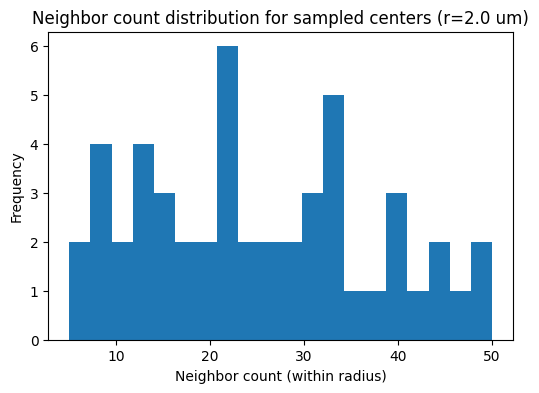

Sampled centers neighbor stats: median = 22.5 , mean = 24.94


In [ ]:
radius = radius_um
print('Using radius =', radius, 'um for neighbor queries')

# choose centers to visualize (uniform sample)
np.random.seed(1)
centers = np.random.choice(N, size=min(sample_n_centers, N), replace=False)
print('Visualizing neighbor links for', len(centers), 'centers')

# store neighbor lines and plotted neighbor point indices
lines_x, lines_y, lines_z = [], [], []
centers_list_x, centers_list_y, centers_list_z = [], [], []
neighbor_point_indices = set()
center_neighbor_counts = []

for ci in centers:
    center_coord = coords[ci]
    neighs = tree.query_ball_point(center_coord, r=radius)
    # remove self if present
    neighs = [n for n in neighs if n != ci]
    center_neighbor_counts.append(len(neighs))
    if len(neighs) == 0:
        # still mark center
        centers_list_x.append(center_coord[0]); centers_list_y.append(center_coord[1]); centers_list_z.append(center_coord[2])
        continue
    # build lines for each neighbor (center -> neighbor)
    for nj in neighs:
        x0,y0,z0 = center_coord
        x1,y1,z1 = coords[nj]
        lines_x += [x0, x1, None]
        lines_y += [y0, y1, None]
        lines_z += [z0, z1, None]
        neighbor_point_indices.add(nj)
    centers_list_x.append(center_coord[0]); centers_list_y.append(center_coord[1]); centers_list_z.append(center_coord[2])

# Prepare neighbor points coords for plotting
neighbor_point_indices = sorted(list(neighbor_point_indices))
neighbor_pts = coords[neighbor_point_indices] if len(neighbor_point_indices) > 0 else np.zeros((0,3))

# Build a combined plot: background (downsampled), neighbor lines, neighbors highlighted, centers highlighted
fig_after = go.Figure()

# background (same as before)
fig_after.add_trace(go.Scatter3d(
    x=bg_coords[:,0], y=bg_coords[:,1], z=bg_coords[:,2],
    mode='markers',
    marker=dict(size=2, color='lightgrey', opacity=0.5),
    name='background (downsampled)'
))

# neighbor lines
if len(lines_x) > 0:
    fig_after.add_trace(go.Scatter3d(
        x=lines_x, y=lines_y, z=lines_z,
        mode='lines',
        line=dict(color='red', width=2),
        name='neighbor links'
    ))

# neighbor points
if len(neighbor_pts) > 0:
    fig_after.add_trace(go.Scatter3d(
        x=neighbor_pts[:,0], y=neighbor_pts[:,1], z=neighbor_pts[:,2],
        mode='markers',
        marker=dict(size=3, color='green', opacity=0.9),
        name=f'neighbors (count={len(neighbor_pts)})'
    ))

# centers
fig_after.add_trace(go.Scatter3d(
    x=centers_list_x, y=centers_list_y, z=centers_list_z,
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.9),
    name='centers (sampled)'
))

fig_after.update_layout(
    title=f'Neighborhood links (r={radius} µm) for sampled centers in FOV {selected_fov}',
    scene=dict(xaxis_title='global_x (um)', yaxis_title='global_y (um)', zaxis_title='global_z (um)')
)

# Save interactive HTML for presentation
html_after = os.path.join(OUTDIR, f'FOV{selected_fov}_neighbors_r{radius:.1f}um.html')
fig_after.write_html(html_after)
print('Saved interactive "after" plot to', html_after)

fig_after.show()

# Quick diagnostic: neighbor counts histogram for sampled centers
plt.figure(figsize=(6,4))
plt.hist(center_neighbor_counts, bins=20)
plt.xlabel('Neighbor count (within radius)')
plt.ylabel('Frequency')
plt.title(f'Neighbor count distribution for sampled centers (r={radius} um)')
plt.show()

print('Sampled centers neighbor stats: median =', np.median(center_neighbor_counts), ', mean =', np.mean(center_neighbor_counts))


### G) - Per-center neighbor gene breakdown for the centers

Print for up to 10 centers with small neighbor lists

In [ ]:
print('Example neighbor gene composition for a few sampled centers:')
max_show = 10
count_shown = 0
for ci in centers[:max_show]:
    neighs = tree.query_ball_point(coords[ci], r=radius)
    neighs = [n for n in neighs if n != ci]
    if len(neighs) == 0:
        print(f'Center idx {ci}: no neighbors within {radius} um')
        count_shown += 1
        continue
    neighbor_genes = df_fov['gene'].astype(str).iloc[neighs].values
    # tally top neighbor genes
    from collections import Counter
    c = Counter(neighbor_genes)
    topN = c.most_common(6)
    print(f'Center idx {ci} (gene={df_fov["gene"].iloc[ci]}): {len(neighs)} neighbors. Top nearby genes: {topN}')
    count_shown += 1
    if count_shown >= max_show:
        break


Example neighbor gene composition for a few sampled centers:
Center idx 104681 (gene=Cx3cl1): 40 neighbors. Top nearby genes: [('Slc17a7', 10), ('Epha4', 4), ('Cx3cl1', 3), ('Celsr2', 2), ('Syt4', 2), ('Nrp2', 2)]
Center idx 129461 (gene=Epha7): 26 neighbors. Top nearby genes: [('Slc17a7', 6), ('Celsr2', 2), ('Grin2b', 2), ('Chrm1', 2), ('Epha4', 2), ('Adgrl3', 1)]
Center idx 126313 (gene=Epha6): 12 neighbors. Top nearby genes: [('Ntrk2', 2), ('Abcc9', 2), ('Slc17a7', 2), ('Axl', 1), ('Htr6', 1), ('Cspg5', 1)]
Center idx 45206 (gene=Npy2r): 12 neighbors. Top nearby genes: [('Slc17a7', 2), ('Gpr162', 2), ('Nrp2', 1), ('Adgrl1', 1), ('Insr', 1), ('Syt4', 1)]
Center idx 85177 (gene=Slc17a7): 39 neighbors. Top nearby genes: [('Slc17a7', 11), ('Epha4', 4), ('Cx3cl1', 3), ('Celsr2', 2), ('Gabbr1', 2), ('Syt4', 2)]
Center idx 38817 (gene=Chrm1): 10 neighbors. Top nearby genes: [('Slc17a7', 4), ('Epha4', 3), ('Gpr26', 1), ('Syt4', 1), ('Epha6', 1)]
Center idx 110505 (gene=Anxa11): 32 neighbors